In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'/content/drive/MyDrive/income_dataset.xlsx'

'/content/drive/MyDrive/income_dataset.xlsx'

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

In [ ]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 150)
PATH = "/content/drive/MyDrive/income_dataset.xlsx"   # <-- AJUSTA
df = pd.read_excel(PATH)

In [ ]:
print(df.shape)
df.head()


(10000, 14)


,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             10000 non-null  int64 
 1   Education_Level                 10000 non-null  object
 2   Occupation                      10000 non-null  object
 3   Number_of_Dependents            10000 non-null  int64 
 4   Location                        10000 non-null  object
 5   Work_Experience                 10000 non-null  int64 
 6   Marital_Status                  10000 non-null  object
 7   Employment_Status               10000 non-null  object
 8   Household_Size                  10000 non-null  int64 
 9   Homeownership_Status            10000 non-null  object
 10  Type_of_Housing                 10000 non-null  object
 11  Gender                          10000 non-null  object
 12  Primary_Mode_of_Transportation  10000 non-null 

### Separar numéricas vs categóricas










In [ ]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object","category","bool"]).columns.tolist()

print("N columnas numéricas:", len(num_cols))
print("N columnas categóricas:", len(cat_cols))
print("\nEjemplo numéricas:", num_cols[:10])
print("Ejemplo categóricas:", cat_cols[:10])

N columnas numéricas: 5
N columnas categóricas: 9

Ejemplo numéricas: ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Income']
Ejemplo categóricas: ['Education_Level', 'Occupation', 'Location', 'Marital_Status', 'Employment_Status', 'Homeownership_Status', 'Type_of_Housing', 'Gender', 'Primary_Mode_of_Transportation']


 Análisis por separado de numéricas vs categóricas






In [ ]:
desc_num = df[num_cols].describe().T
card_cat = df[cat_cols].nunique(dropna=False).sort_values(ascending=False).to_frame("n_unique")

In [ ]:
desc_num

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,44.0217,1.520400e+01,18.0,31.0,44.0,57.0,70.0
Number_of_Dependents,10000.0,2.5270,1.713991e+00,0.0,1.0,3.0,4.0,5.0
Work_Experience,10000.0,24.8588,1.465262e+01,0.0,12.0,25.0,37.0,50.0
Household_Size,10000.0,3.9896,2.010496e+00,1.0,2.0,4.0,6.0,7.0
Income,10000.0,816838.1667,1.821089e+06,31044.0,68446.0,72943.0,350667.5,9992571.0


In [ ]:
card_cat

,n_unique
Occupation,5
Education_Level,4
Primary_Mode_of_Transportation,4
Marital_Status,3
Location,3
Employment_Status,3
Type_of_Housing,3
Homeownership_Status,2
Gender,2


In [ ]:
desc_num.to_excel("desc_num.xlsx")
card_cat.to_excel("card_cat.xlsx")

Quantiles (colas y outliers)


In [ ]:
quantiles_num = (
    df[num_cols]
    .quantile([0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99])
    .T
)

quantiles_num


,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
Age,18.00,20.0,23.0,31.0,44.0,57.0,65.0,68.00,70.00
Number_of_Dependents,0.00,0.0,0.0,1.0,3.0,4.0,5.0,5.00,5.00
Work_Experience,0.00,2.0,4.0,12.0,25.0,37.0,45.0,48.00,50.00
Household_Size,1.00,1.0,1.0,2.0,4.0,6.0,7.0,7.00,7.00
Income,36121.95,64149.7,65766.0,68446.0,72943.0,350667.5,2890510.4,5343905.45,8836918.82


Diagnóstico de calidad de datos



In [ ]:
n_duplicates = df.duplicated().sum()
print("Duplicados:", n_duplicates)


Duplicados: 0


In [ ]:
df[num_cols].info()

# Missing real
df[num_cols].isna().mean().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   10000 non-null  int64
 1   Number_of_Dependents  10000 non-null  int64
 2   Work_Experience       10000 non-null  int64
 3   Household_Size        10000 non-null  int64
 4   Income                10000 non-null  int64
dtypes: int64(5)
memory usage: 390.8 KB


,0
Age,0.0
Number_of_Dependents,0.0
Work_Experience,0.0
Household_Size,0.0
Income,0.0


In [ ]:
df[cat_cols].isna().mean().sort_values(ascending=False)

,0
Education_Level,0.0
Occupation,0.0
Location,0.0
Marital_Status,0.0
Employment_Status,0.0
Homeownership_Status,0.0
Type_of_Housing,0.0
Gender,0.0
Primary_Mode_of_Transportation,0.0


5 valores más frecuentes (numéricas)





In [ ]:
top5_num = {}
for col in num_cols[:10]:
    top5_num[col] = df[col].value_counts(dropna=False).head(5)

top5_num

{'Age': Age
 43    223
 66    216
 62    215
 40    212
 64    209
 Name: count, dtype: int64,
 'Number_of_Dependents': Number_of_Dependents
 5    1745
 3    1712
 1    1651
 0    1642
 4    1629
 Name: count, dtype: int64,
 'Work_Experience': Work_Experience
 2     224
 44    221
 48    219
 24    218
 33    216
 Name: count, dtype: int64,
 'Household_Size': Household_Size
 1    1477
 3    1445
 6    1437
 7    1433
 5    1411
 Name: count, dtype: int64,
 'Income': Income
 74306    10
 71180     7
 72296     6
 68116     6
 74294     6
 Name: count, dtype: int64}

5 valores más frecuentes (categóricas)



In [ ]:
for col in cat_cols[:5]:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).head(5))
    display(df[col].value_counts(normalize=True, dropna=False).head(5))


--- Education_Level ---


,count
Education_Level,
Bachelor's,4058
High School,2959
Master's,2482
Doctorate,501


,proportion
Education_Level,
Bachelor's,0.4058
High School,0.2959
Master's,0.2482
Doctorate,0.0501



--- Occupation ---


,count
Occupation,
Healthcare,3035
Technology,2407
Finance,1525
Others,1521
Education,1512


...

,count
Marital_Status,
Married,5136
Single,3900
Divorced,964


,proportion
Marital_Status,
Married,0.5136
Single,0.3900
Divorced,0.0964



--- Employment_Status ---


,count
Employment_Status,
Full-time,5004
Part-time,3016
Self-employed,1980


,proportion
Employment_Status,
Full-time,0.5004
Part-time,0.3016
Self-employed,0.1980


In [ ]:
with pd.ExcelWriter("frecuencias_categoricas.xlsx") as writer:
    for col in cat_cols[:10]:
        vc_abs = df[col].value_counts(dropna=False).head(5)
        vc_rel = df[col].value_counts(normalize=True, dropna=False).head(5)

        out = pd.DataFrame({
            "conteo": vc_abs,
            "proporcion": vc_rel
        })

        out.to_excel(writer, sheet_name=col[:31])


Outliers


In [ ]:
outlier_table = pd.DataFrame({
    "min": df[num_cols].min(),
    "p1": df[num_cols].quantile(0.01),
    "p50": df[num_cols].quantile(0.50),
    "p99": df[num_cols].quantile(0.99),
    "max": df[num_cols].max(),
}).sort_values("p99", ascending=False)

outlier_table.head(30)

,min,p1,p50,p99,max
Income,31044,36121.95,72943.0,8836918.82,9992571
Age,18,18.00,44.0,70.00,70
Work_Experience,0,0.00,25.0,50.00,50
Household_Size,1,1.00,4.0,7.00,7
Number_of_Dependents,0,0.00,3.0,5.00,5


Preprocesamiento


In [ ]:
## no se encontararoon valores duplicados anteriormente
df[cat_cols] = df[cat_cols].apply(
    lambda s: s.astype(str).str.strip().replace({"?": np.nan, "": np.nan})
)

Análisis Exploratorio (EDA univariado) y Visualización

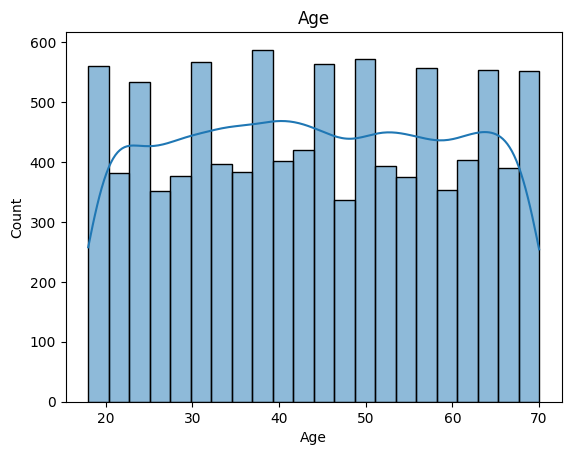

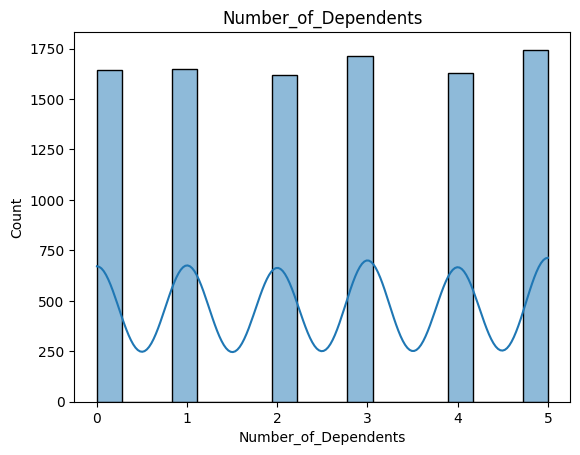

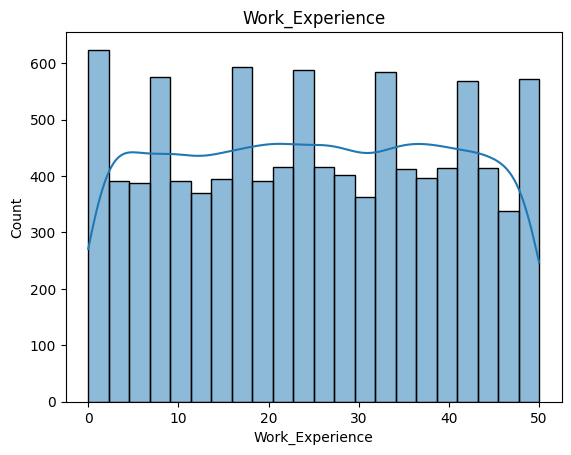

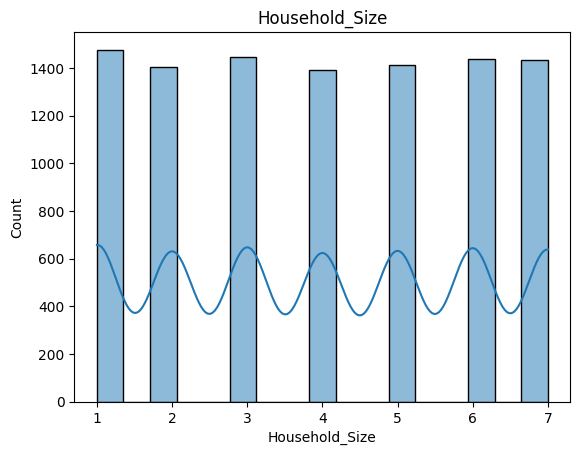

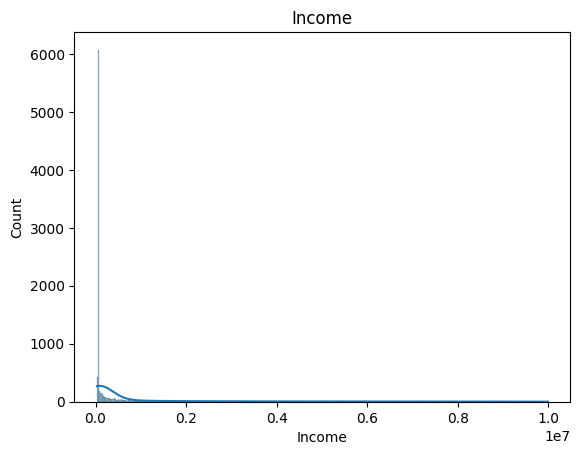

In [ ]:

for col in num_cols[:5]:  # limitar para no saturar
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

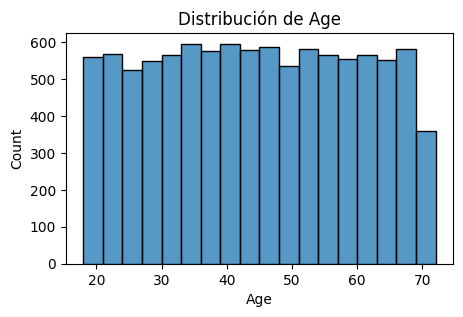

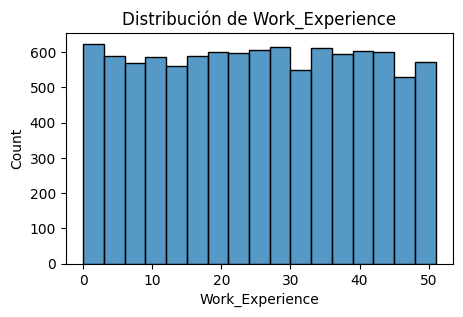

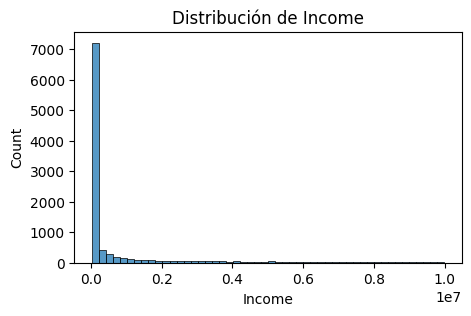

In [ ]:
for col in ["Age", "Work_Experience", "Income"]:
    data = df[col].dropna()

    plt.figure(figsize=(5, 3))

    if col == "Income":
        sns.histplot(data, bins=50)
    else:
        min_v = int(data.min())
        max_v = int(data.max())
        bins = np.arange(min_v, max_v + 4, 3)
        sns.histplot(data, bins=bins)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.show()


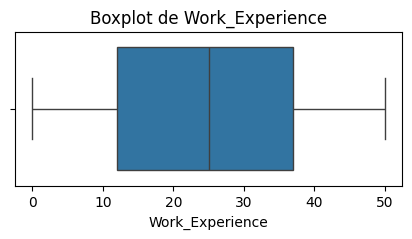

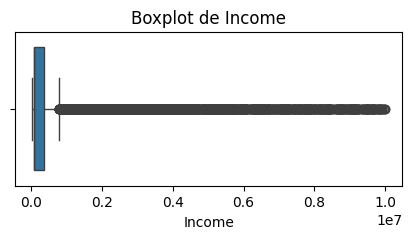

In [ ]:
for col in ["Work_Experience", "Income"]:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

    ## el Boxplot de experiencia laboral indica que la mayoria de los individuos se acumulan entre los 25 años como media. No hay valores atipicos
    ## para el caso de income

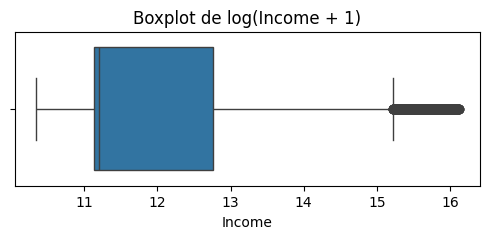

In [ ]:
## se procedio a usar logaritmos para que la caja tenga mayor
## visualizacion y los outliers sean visibles a diferencia del anterior grafico

plt.figure(figsize=(6,2))
sns.boxplot(x=np.log1p(df["Income"]))
plt.title("Boxplot de log(Income + 1)")
plt.show()

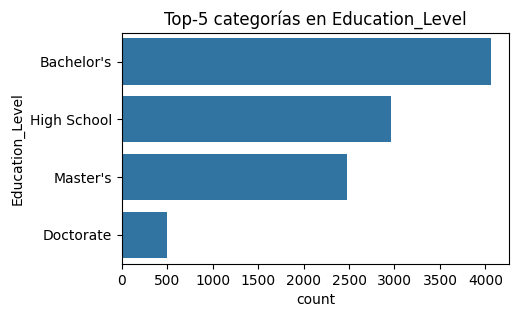

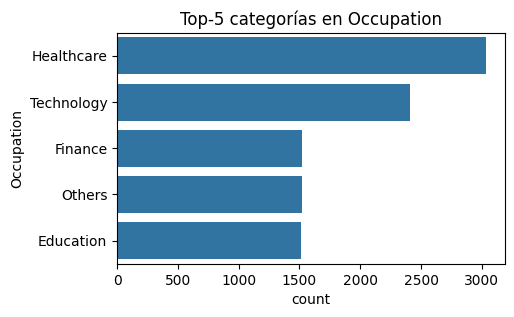

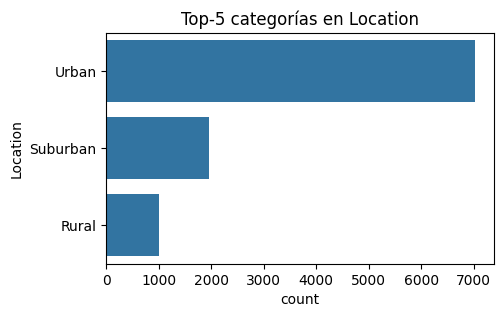

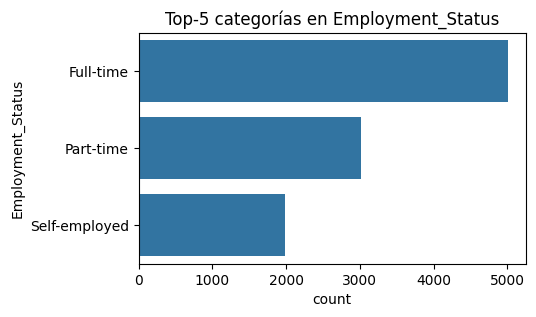

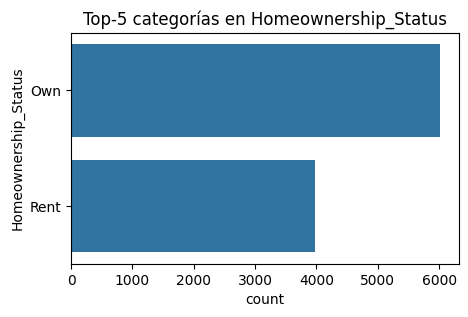

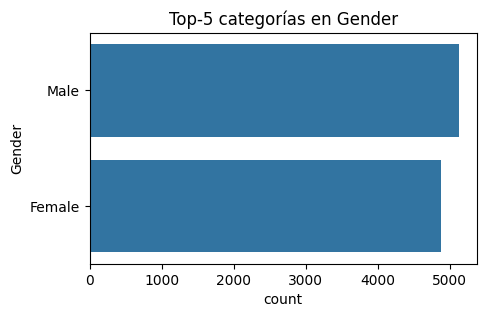

In [ ]:
cat_example = ["Education_Level", "Occupation", "Location","Employment_Status","Homeownership_Status","Gender"]     ## solo se muestran 4 categorías

for col in cat_example:
    plt.figure(figsize=(5,3))
    top = df[col].value_counts().head(5).index
    sns.countplot(y=df[col], order=top)
    plt.title(f"Top-5 categorías en {col}")
    plt.show()

#Entrega 3



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

In [ ]:
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
df["log_Income"] = np.where(
    df["Income"] > 0,
    np.log(df["Income"]),
    np.nan
)
df["Income_monthly"] = df["Income"] / 12
df["log_Income_monthly"] = np.where(
    df["Income_monthly"] > 0,
    np.log(df["Income_monthly"]),
    np.nan
)
df[["Income", "log_Income", "Income_monthly", "log_Income_monthly"]].head(10)


,Income,log_Income,Income_monthly,log_Income_monthly
0,72510,11.191480,6042.500000,8.706573
1,75462,11.231384,6288.500000,8.746478
2,71748,11.180915,5979.000000,8.696009
3,74520,11.218823,6210.000000,8.733916
4,640210,13.369552,53350.833333,10.884645
5,73406,11.203761,6117.166667,8.718854
6,3584362,15.092091,298696.833333,12.607184
7,70066,11.157193,5838.833333,8.672286
8,69636,11.151037,5803.000000,8.666130
9,5188124,15.461883,432343.666667,12.976976


In [ ]:
df[["Income", "log_Income", "Income_monthly", "log_Income_monthly"]].head()


,Income,log_Income,Income_monthly,log_Income_monthly
0,72510,11.191480,6042.500000,8.706573
1,75462,11.231384,6288.500000,8.746478
2,71748,11.180915,5979.000000,8.696009
3,74520,11.218823,6210.000000,8.733916
4,640210,13.369552,53350.833333,10.884645


Análisis de calidad      


In [ ]:
df.isna().mean().sort_values(ascending=False)

df.nunique().sort_values()   #verificamos los valores únicos de cada variable categorica y conitnua


,0
Gender,2
Homeownership_Status,2
Marital_Status,3
Employment_Status,3
Location,3
Type_of_Housing,3
Primary_Mode_of_Transportation,4
Education_Level,4
Occupation,5
Number_of_Dependents,6


Revisión de nulos en la variable ingreso


In [ ]:
(df["Income"] <= 0).sum()

np.int64(0)

Preparación


In [ ]:

df["log_Income"] = np.log(df["Income"])

##Conversión todas las variables categóricas listadas en variables dummy (0/1
cat_vars = [
    "Education_Level", "Occupation", "Location", "Marital_Status",
    "Employment_Status", "Gender", "Homeownership_Status",
    "Type_of_Housing", "Primary_Mode_of_Transportation"
]

df_dummies = pd.get_dummies(df, columns=cat_vars, drop_first=True)
df


,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income,log_Income,Income_monthly,log_Income_monthly
0,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510,11.191480,6042.500000,8.706573
1,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462,11.231384,6288.500000,8.746478
2,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748,11.180915,5979.000000,8.696009
3,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520,11.218823,6210.000000,8.733916
4,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210,13.369552,53350.833333,10.884645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,58,High School,Others,0,Suburban,26,Divorced,Full-time,6,Own,Townhouse,Female,Car,74994,11.225163,6249.500000,8.740257
9996,23,Master's,Technology,3,Urban,16,Divorced,Full-time,1,Own,Single-family home,Female,Biking,72676,11.193766,6056.333333,8.708860
9997,41,Doctorate,Education,3,Urban,50,Single,Full-time,4,Own,Single-family home,Female,Public transit,2684820,14.803124,223735.000000,12.318218
9998,44,High School,Education,0,Urban,3,Married,Part-time,1,Own,Single-family home,Male,Biking,57955,10.967422,4829.583333,8.482515


En el siguiente grafico se aprecia que hay mucha variación de ingresos para el mismo nivel de experiencia

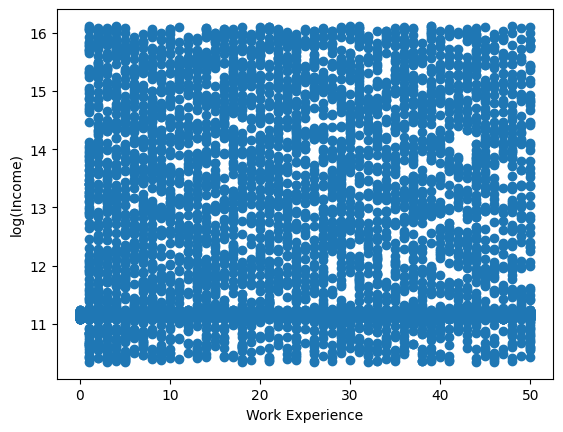

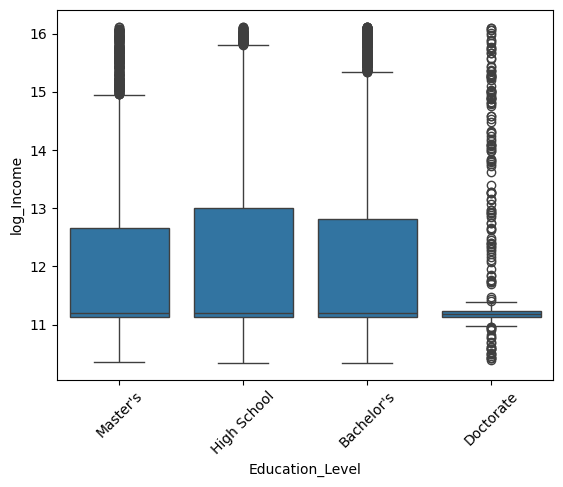

In [ ]:
plt.scatter(df["Work_Experience"], df["log_Income"])
plt.xlabel("Work Experience")
plt.ylabel("log(Income)")
plt.show()

# Categórica vs target
import seaborn as sns
sns.boxplot(x="Education_Level", y="log_Income", data=df)
plt.xticks(rotation=45)
plt.show()

# Lineal Regretion






In [ ]:
variables = [
    'Primary_Mode_of_Transportation',
    'Income_monthly',
    'log_Income_monthly',
    'Income'
]

data = df.drop(variables, axis=1)
data.columns

Index(['Age', 'Education_Level', 'Occupation', 'Number_of_Dependents', 'Location', 'Work_Experience', 'Marital_Status', 'Employment_Status',
       'Household_Size', 'Homeownership_Status', 'Type_of_Housing', 'Gender', 'log_Income'],
      dtype='object')

In [ ]:
numericas = data.select_dtypes(include='number')
categoricas = data.select_dtypes(include=['object','category'])

In [ ]:
numericas.columns.values  #Comprobamos las varaibles numericas y categoricas

array(['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size',
       'log_Income'], dtype=object)

In [ ]:
categoricas.columns.values

array(['Education_Level', 'Occupation', 'Location', 'Marital_Status',
       'Employment_Status', 'Homeownership_Status', 'Type_of_Housing',
       'Gender'], dtype=object)

# Train y Test


In [ ]:
variables_string = data.select_dtypes(include='object').columns
print(variables_string)

Index(['Education_Level', 'Occupation', 'Location', 'Marital_Status', 'Employment_Status', 'Homeownership_Status', 'Type_of_Housing', 'Gender'], dtype='object')


In [ ]:
variables_con_nan = data.columns[data.isna().any()].tolist()
print("Variables con valores NaN:")
print(variables_con_nan)

Variables con valores NaN:
[]


In [ ]:
# Variable objetivo
y = data['log_Income']

# Variables explicativas
X = data.drop('log_Income', axis=1)

In [ ]:
X = pd.get_dummies(X, drop_first=True)
X.dtypes

,0
Age,int64
Number_of_Dependents,int64
Work_Experience,int64
Household_Size,int64
Education_Level_Doctorate,bool
Education_Level_High School,bool
Education_Level_Master's,bool
Occupation_Finance,bool
Occupation_Healthcare,bool
Occupation_Others,bool


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verificación
print('Forma de X_train:', X_train.shape)
print('Forma de y_train:', y_train.shape)
print('Forma de X_test:', X_test.shape)
print('Forma de y_test:', y_test.shape)


Forma de X_train: (8000, 21)
Forma de y_train: (8000,)
Forma de X_test: (2000, 21)
Forma de y_test: (2000,)


In [ ]:
X_train.head()

,Age,Number_of_Dependents,Work_Experience,Household_Size,Education_Level_Doctorate,Education_Level_High School,Education_Level_Master's,Occupation_Finance,Occupation_Healthcare,Occupation_Others,Occupation_Technology,Location_Suburban,Location_Urban,Marital_Status_Married,Marital_Status_Single,Employment_Status_Part-time,Employment_Status_Self-employed,Homeownership_Status_Rent,Type_of_Housing_Single-family home,Type_of_Housing_Townhouse,Gender_Male
9254,44,4,27,7,False,False,False,False,False,False,True,False,True,False,True,True,False,False,True,False,False
1561,45,2,19,7,False,False,False,False,True,False,False,True,False,True,False,False,False,True,True,False,False
1670,68,5,26,5,True,False,False,False,False,False,False,False,False,False,True,True,False,False,True,False,True
6087,53,0,25,1,False,False,True,False,False,False,True,False,True,True,False,False,False,False,False,False,True
6669,44,2,16,6,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False


In [ ]:
y_train.head()

,log_Income
9254,11.228066
1561,13.498396
1670,11.144120
6087,11.216324
6669,11.229103


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

y = data["log_Income"]
X = data.drop("log_Income", axis=1)

X = pd.get_dummies(X, drop_first=True)

#  Detectar si aún hay columnas object antes de convertir
obj_cols_before = X.columns[X.dtypes == "object"].tolist()
print("Object antes de convertir:", obj_cols_before[:10], "..." if len(obj_cols_before)>10 else "")
print("N° object antes:", len(obj_cols_before))

#  Convertir  a numérico
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

#) Reemplazar inf/-inf por NaN
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)


df_model = pd.concat([y.rename("log_Income"), X], axis=1).dropna()

y_clean = df_model["log_Income"]
X_clean = df_model.drop("log_Income", axis=1)

# Agregar constante
X_clean = sm.add_constant(X_clean)

obj_cols_after = X_clean.columns[X_clean.dtypes == "object"].tolist()
print("Object después (debería ser 0):", obj_cols_after)
print("Shapes:", X_clean.shape, y_clean.shape)

X_clean = X_clean.astype(float)
y_clean = y_clean.astype(float)

# 10) OLS
model = sm.OLS(y_clean, X_clean).fit()
print(model.summary())




Object antes de convertir: [] 
N° object antes: 0
Object después (debería ser 0): []
Shapes: (10000, 22) (10000,)
                            OLS Regression Results                            
Dep. Variable:             log_Income   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     17.83
Date:                Mon, 02 Feb 2026   Prob (F-statistic):           3.86e-65
Time:                        00:03:21   Log-Likelihood:                -18205.
No. Observations:               10000   AIC:                         3.645e+04
Df Residuals:                    9978   BIC:                         3.661e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      

#Entrenar un modelo de Arbol de Decisión usando DecisionTreeRegressor (DT).


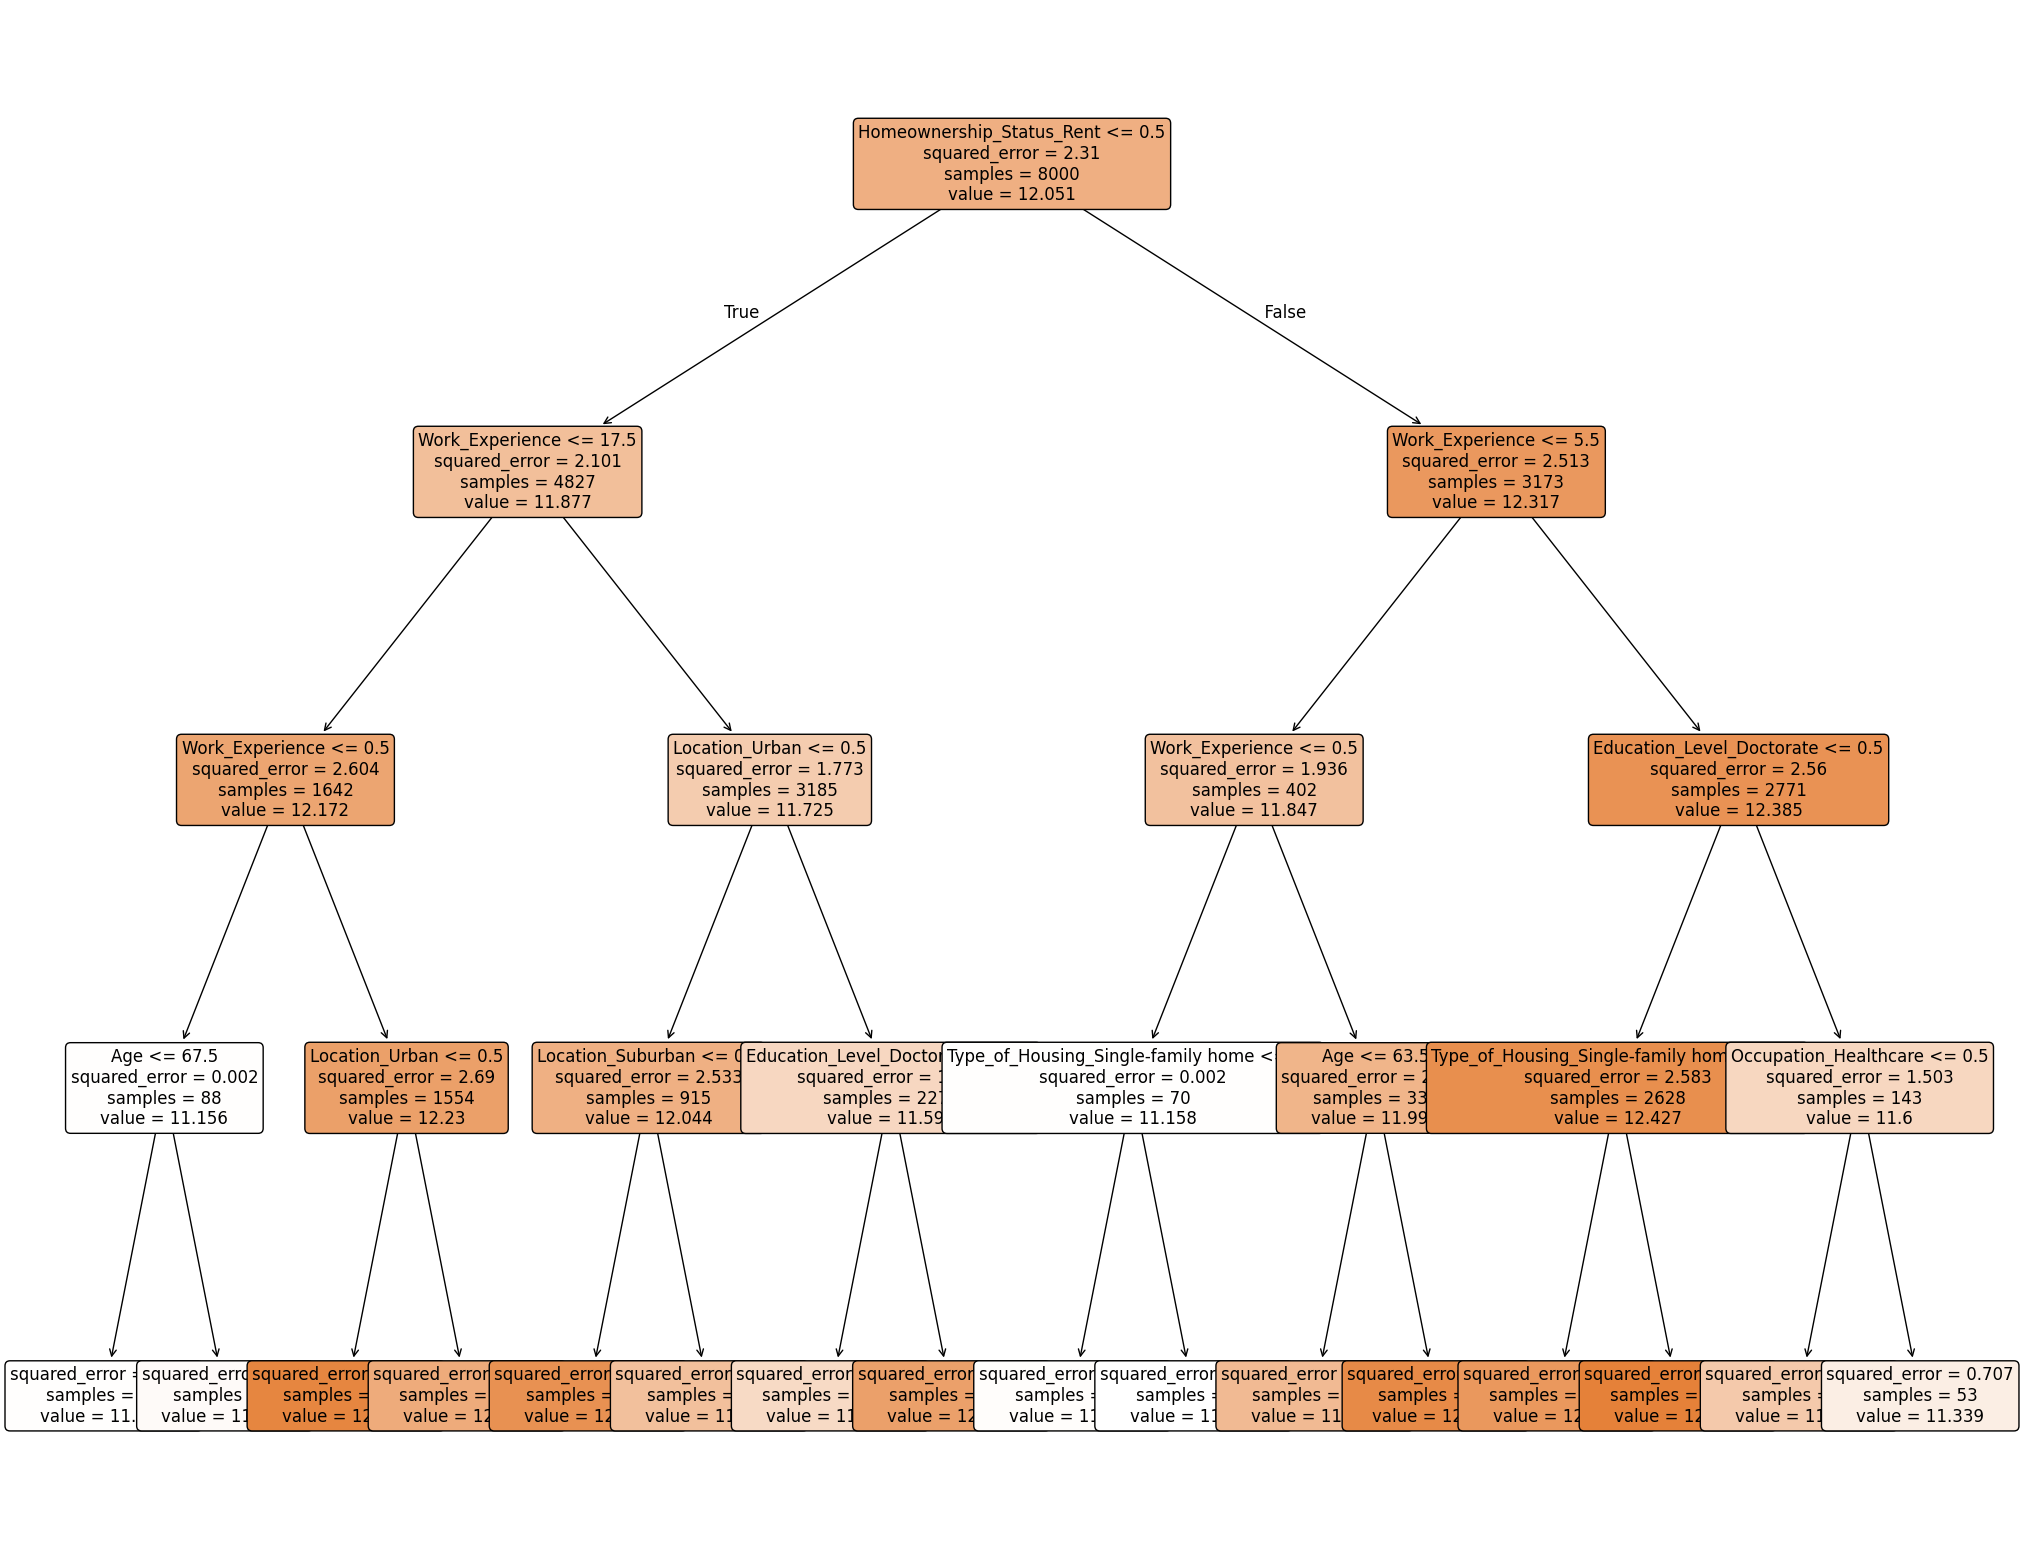

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 20))

# Árbol de decisión para la regresion
DT = DecisionTreeRegressor(max_depth=4, random_state=42)
DT.fit(X_train, y_train)

# Graficar arbol
tree.plot_tree(
    DT,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=12
)

plt.show()

En el primer nodo del arbol de decision se verifica que la dirección de la rama se da por la condicion de vivienda. Luego  la experiencia laboral . Por ejemplo si una persona es propietaria pero posee poca experiencia , va a presentar ingresos anuales bajos de 12.172 (ln) .Las ramas dirigidas a la izquierda indica a los que cumlen (en este caso las que no alquilan) mientras que la rama derecha los que no cumplen.

#Entrenar un modelo de Ensamble homogéneo usando RandomForestClassifier (RF).

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:


# =========================

# =========================
y = data["log_Income"]
X = data.drop("log_Income", axis=1)


X = pd.get_dummies(X, drop_first=True)


X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
y = pd.to_numeric(y, errors="coerce").replace([np.inf, -np.inf], np.nan)

df_model = pd.concat([y.rename("log_Income"), X], axis=1).dropna()
y = df_model["log_Income"]
X = df_model.drop("log_Income", axis=1)


# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


param_grid = {
    "n_estimators": [150, 200, 250],     # número de árboles
    "max_leaf_nodes": [12, 14, 16],      # máximo de nodos hoja
    "max_features": [5, 6, 7],           # variables consideradas en cada split
    "min_samples_leaf": [1, 2, 3]        # mínimo de muestras por hoja
}


grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",       # para regresión: R²
    cv=5,               # validación cruzada 5-fold
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor R² (CV):", grid.best_score_)

#6) Evaluación en test
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nR² (test):", r2)
print("RMSE (test):", rmse)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores hiperparámetros: {'max_features': 7, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'n_estimators': 200}
Mejor R² (CV): 0.06312224430723774

R² (test): 0.06292890193154599
RMSE (test): 1.4803317038411337


#Evaluación de Modelos : Comparación de métricas



In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)

    y_train_pred = modelo.predict(X_train)
    y_test_pred  = modelo.predict(X_test)

    return {
        "Nombre del Modelo": nombre,
        "MSE Train": mean_squared_error(y_train, y_train_pred),
        "MAE Train": mean_absolute_error(y_train, y_train_pred),
        "R2 Train": r2_score(y_train, y_train_pred),
        "MSE Test": mean_squared_error(y_test, y_test_pred),
        "MAE Test": mean_absolute_error(y_test, y_test_pred),
        "R2 Test": r2_score(y_test, y_test_pred),
    }


lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=grid.best_params_["n_estimators"],
    max_leaf_nodes=grid.best_params_["max_leaf_nodes"],
    max_features=grid.best_params_["max_features"],
    min_samples_leaf=grid.best_params_["min_samples_leaf"],
    random_state=42,
    n_jobs=-1
)

nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)


resultados = []

resultados.append(evaluar_modelo(
    "Regresión Lineal", lr, X_train, X_test, y_train, y_test
))

resultados.append(evaluar_modelo(
    "Random Forest", rf, X_train, X_test, y_train, y_test
))

resultados.append(evaluar_modelo(
    "Red Neuronal", nn, X_train, X_test, y_train, y_test
))


tabla_resultados = pd.DataFrame(resultados)

tabla_resultados = tabla_resultados.round(2)

tabla_resultados


,Nombre del Modelo,MSE Train,MAE Train,R2 Train,MSE Test,MAE Test,R2 Test
0,Regresión Lineal,2.23,1.19,0.04,2.26,1.21,0.03
1,Random Forest,2.12,1.17,0.08,2.19,1.20,0.06
2,Red Neuronal,0.96,0.67,0.58,1.19,0.76,0.49


#Gráficos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

In [ ]:
coef_lr = pd.Series(
    np.abs(lr.coef_),
    index=X.columns
).sort_values(ascending=False).head(10)


In [ ]:
imp_rf = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

In [ ]:
perm_nn = permutation_importance(
    nn, X_train, y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_nn = pd.Series(
    perm_nn.importances_mean,
    index=X.columns
).sort_values(ascending=False).head(10)

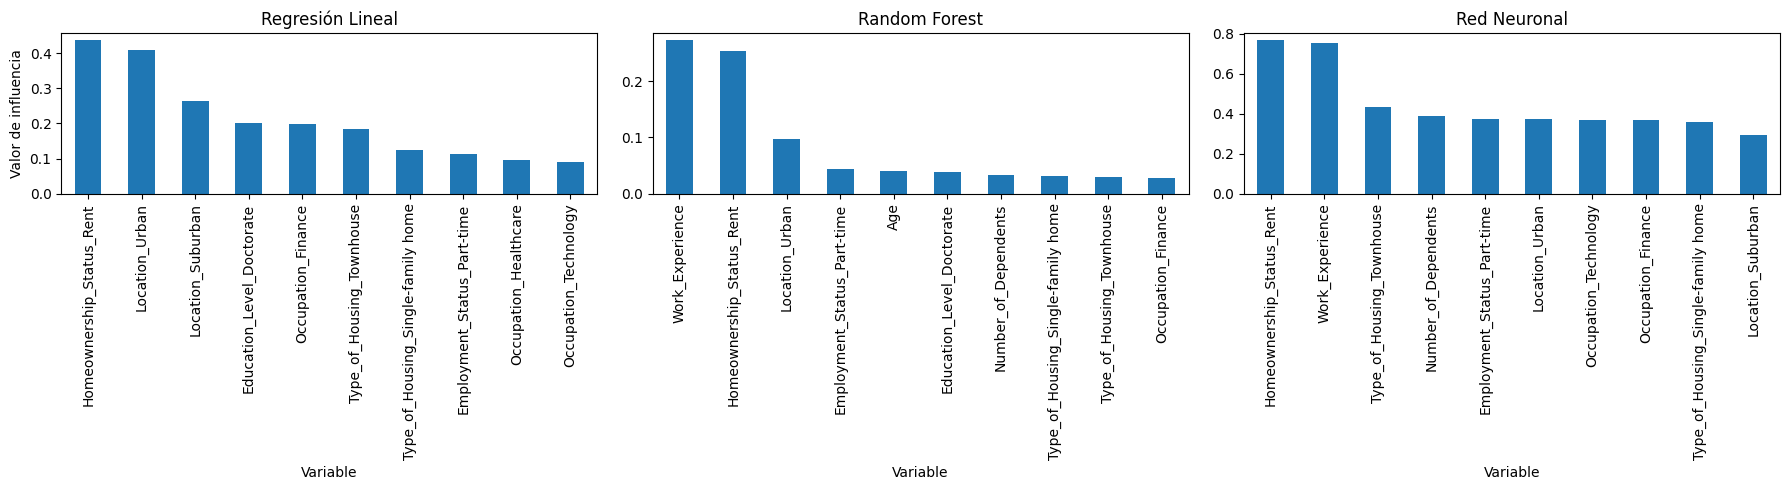

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Regresión Lineal
coef_lr.plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Regresión Lineal")
axes[0].set_ylabel("Valor de influencia")
axes[0].set_xlabel("Variable")

# Random Forest
imp_rf.plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Variable")

# Red Neuronal
imp_nn.plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("Red Neuronal")
axes[2].set_xlabel("Variable")

plt.tight_layout()
plt.show()
